<strong>IRIS FLOWER CLASSIFICATION</strong>

In [3]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')


plt.style.use("fivethirtyeight")
%matplotlib inline

In [4]:
df=pd.read_csv("data/iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
#information about the dataset
print(df.shape)        # Rows and columns
print(df.columns)      # Column names
df.info()              # Data types
df.describe()          # Statistical summary

(150, 6)
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


### Check Missing Values

In [6]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [7]:
df.drop(columns=['Id'], inplace=True)

In [8]:
#count the value
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [9]:
#finding the null value
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [10]:
df.drop_duplicates(inplace=True)

# EDA 

### 1. Relationship between species and sepal length

<Axes: xlabel='Species', ylabel='SepalLengthCm'>

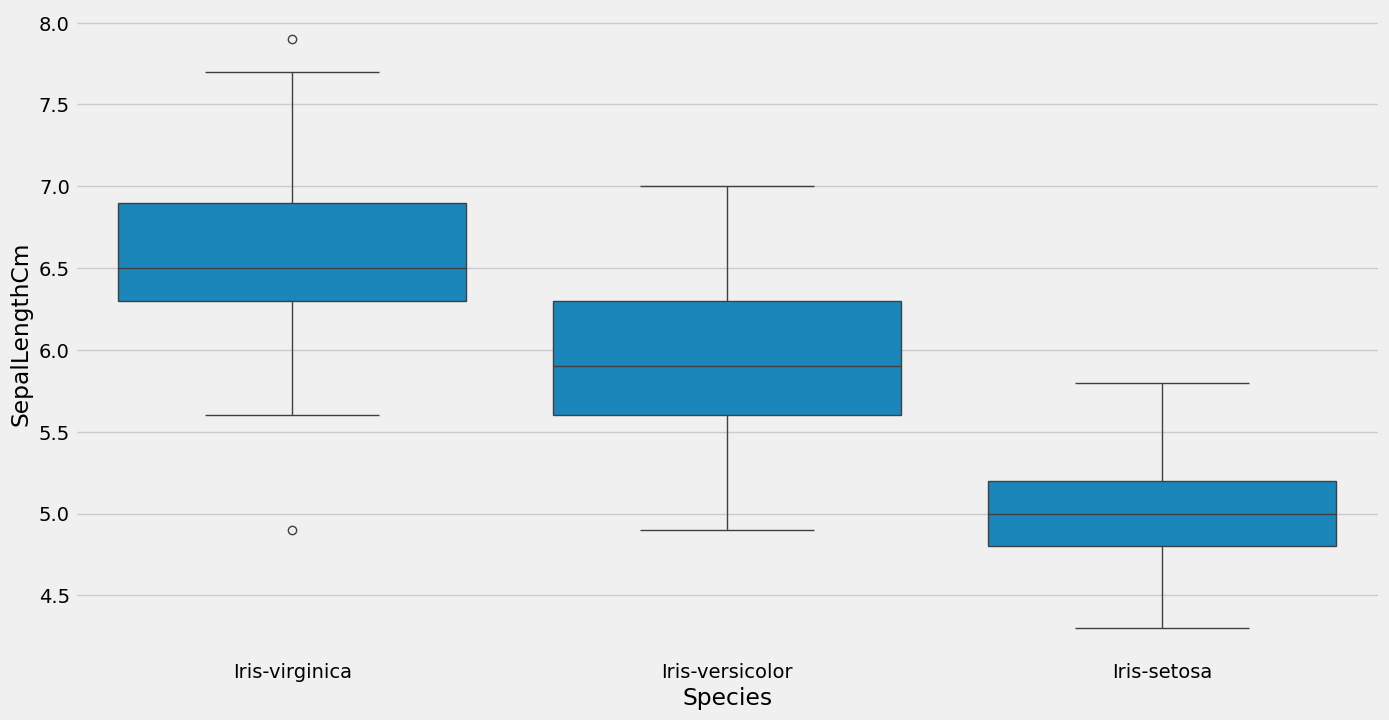

In [11]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Species',y='SepalLengthCm',data=df.sort_values('SepalLengthCm',ascending=False))

### 2. Relationship between species and sepal width

<Axes: xlabel='SepalWidthCm', ylabel='SepalLengthCm'>

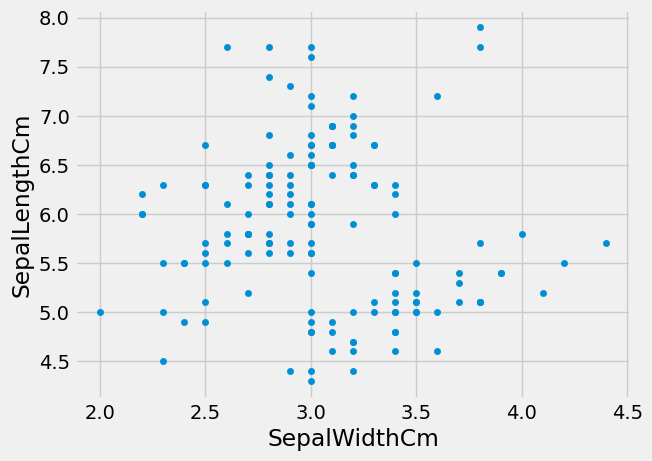

In [12]:
df.plot(kind='scatter',x='SepalWidthCm',y='SepalLengthCm')

### 3. Relationship between sepal width and sepal length

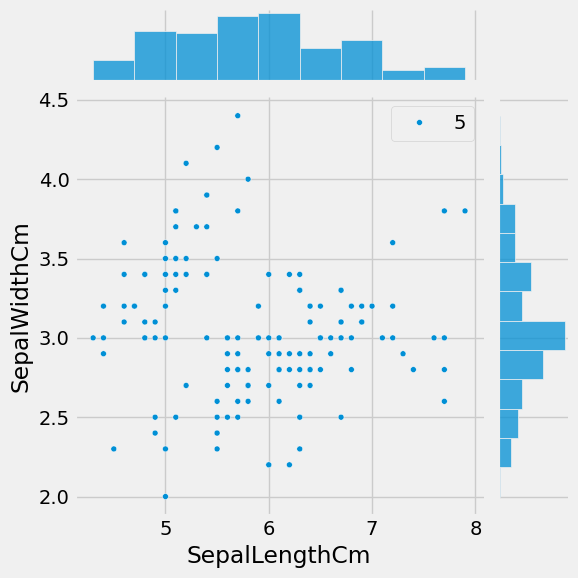

In [13]:
sns.jointplot(x="SepalLengthCm", y="SepalWidthCm", data=df, size=5)

### 4.Univariate Analysis

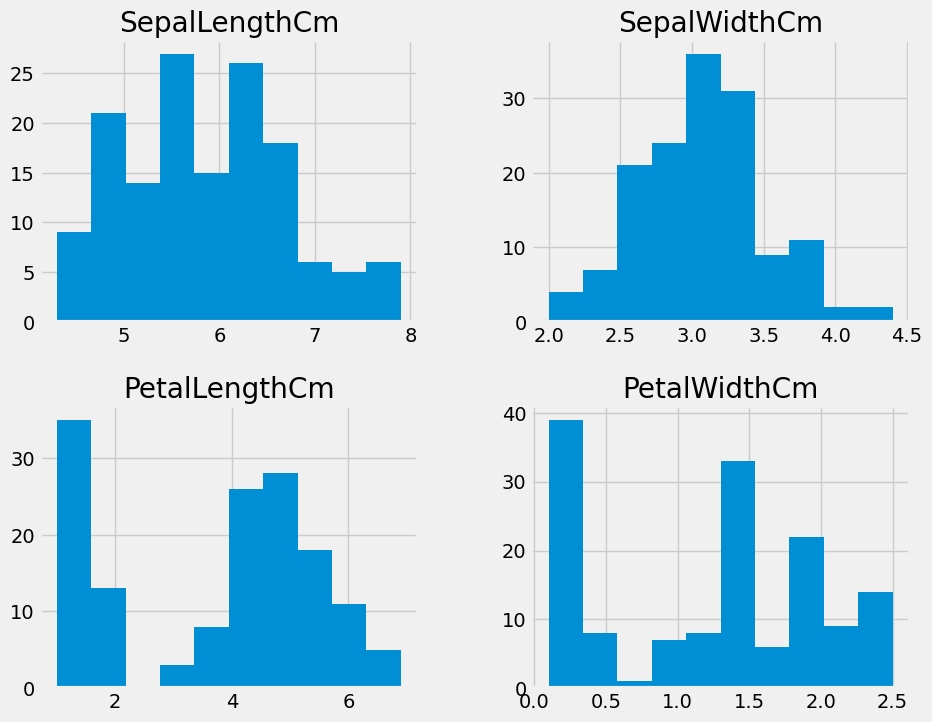

In [14]:
#Histogram (Feature Distribution)
df.hist(figsize=(10,8))
plt.show()

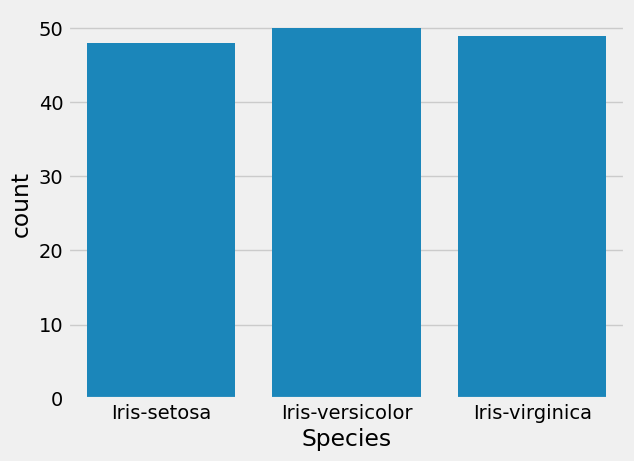

In [15]:
#Target Variable Count
sns.countplot(x='Species', data=df)
plt.show()

### 5. Bivariate Analysis

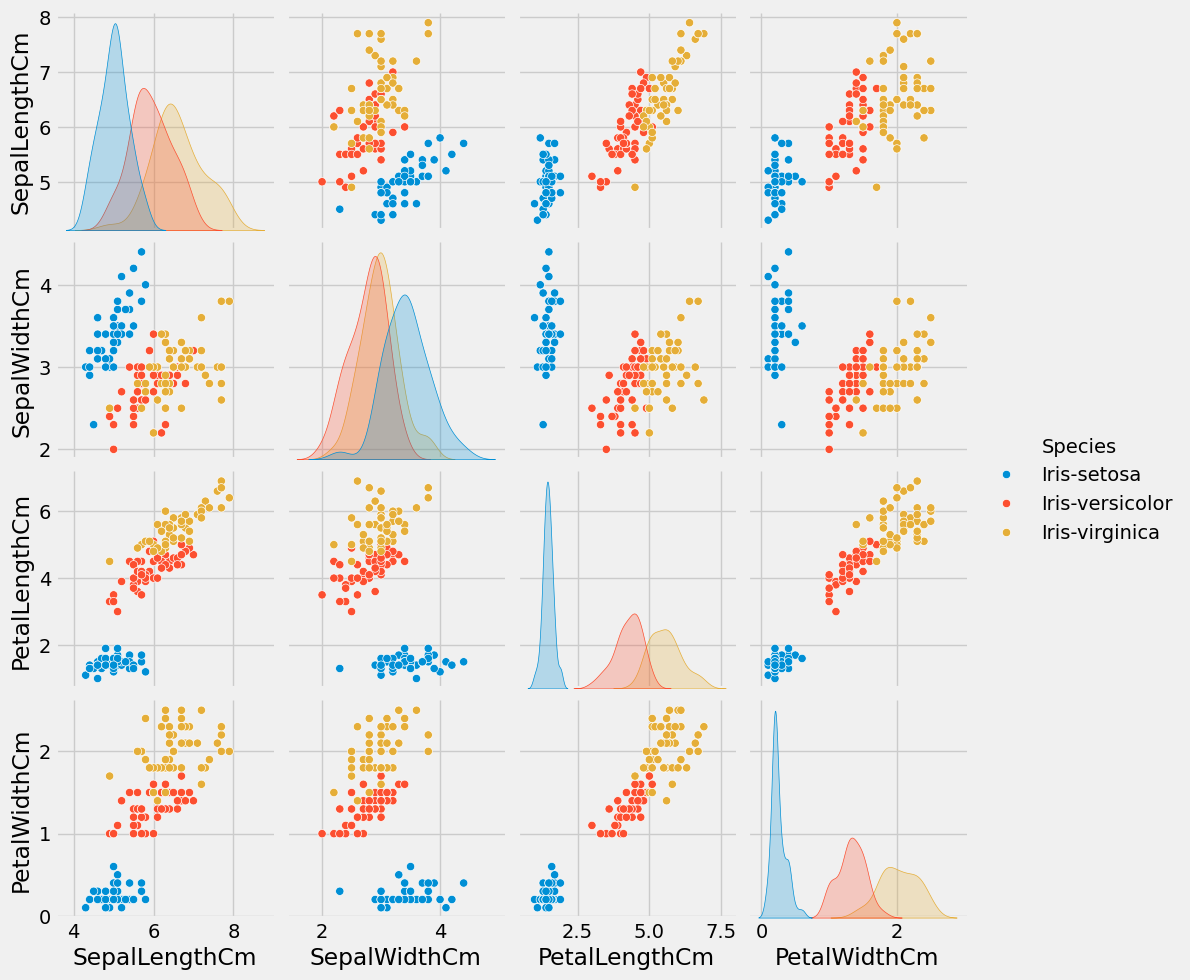

In [16]:
#Pairplot
sns.pairplot(df, hue='Species')
plt.show()

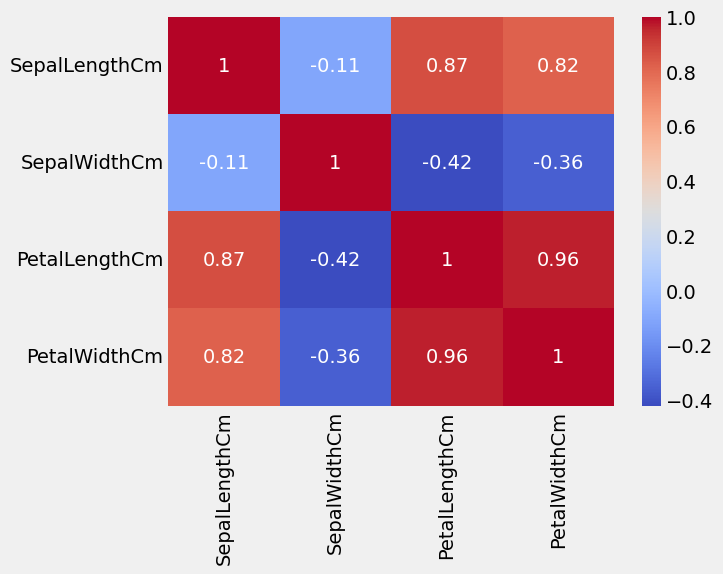

In [17]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

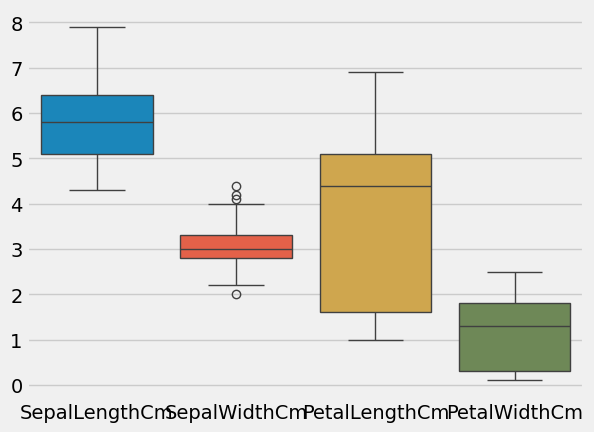

In [18]:
#Outlier Detection
sns.boxplot(data=df)
plt.show()


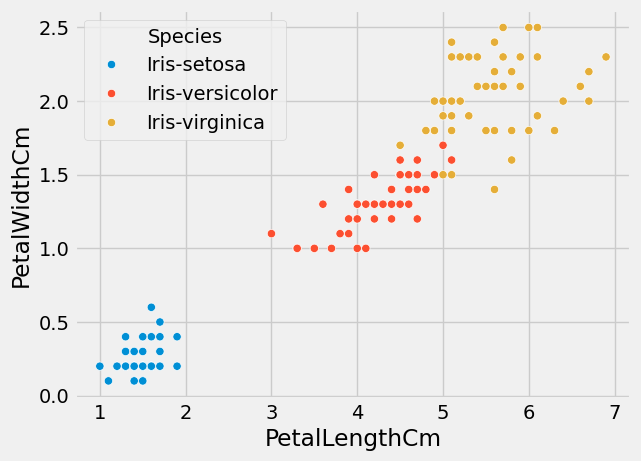

In [19]:
#Feature Relationships
sns.scatterplot(
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='Species',
    data=df
)
plt.show()


### 6. Data Preprocessing

In [20]:
#Encode Target Variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Species'] = le.fit_transform(df['Species'])

In [21]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

X = df.drop('Species', axis=1)
y = df['Species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled['Species'] = y

In [24]:
#Save Preprocessed Data
df_scaled.to_csv("processed_iris.csv", index=False)

### 7. Conclusion and Insights
- Dataset understanding achieved
The structure, data types, and distribution of features were clearly identified through initial analysis.
- Data quality ensured
Missing values and unnecessary columns were handled, resulting in a clean and reliable dataset.
- Feature importance identified
Petal length and petal width were found to be the most significant features for classification.
- Relationships and patterns observed
Strong correlations and clear class separability were identified using pairplots and heatmaps.
- Data prepared for modeling
Encoding and scaling transformed the dataset into a suitable format for machine learning and deep learning models.